# Part 1 — Dataset Exploration
## Plant Disease Classification Project

**Objective:** Understand the PlantVillage dataset structure, verify class balance,
visualize representative samples, and confirm the train/val/test split strategy
before any modeling work begins.

---
**Pipeline Reference:** `plant_disease_project_plan.md`  
**Split Strategy:** 70% Train / 15% Validation / 15% Test (stratified, `random_state=42`)  
**Target classes:** 10 PlantVillage classes  

## 0. Environment Setup

In [11]:
import sys, json, warnings
from pathlib import Path
from collections import Counter
import datetime

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Path setup: add project root so `src` imports work ───────────────────────
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    load_image_rgb, preprocess_image, preprocess_for_segmentation,
    TARGET_SIZE, GAUSSIAN_KERNEL
)
from src.data_loader import (
    discover_dataset, make_splits, print_split_summary,
    compute_class_weights, imbalance_ratio,
    RANDOM_STATE, TRAIN_RATIO, VAL_RATIO
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Output directories ────────────────────────────────────────────────────────
RESULTS_DIR  = PROJECT_ROOT / 'results'
PLOTS_DIR    = RESULTS_DIR / 'plots' / 'part1_exploration'
LOGS_DIR     = RESULTS_DIR / 'experiment_logs'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Environment ready.')
print(f'   Project root : {PROJECT_ROOT}')
print(f'   Plots saved  : {PLOTS_DIR}')
print(f'   Logs saved   : {LOGS_DIR}')

✅ Environment ready.
   Project root : C:\Users\errac\Desktop\Projet_ING\Computer-Vision
   Plots saved  : C:\Users\errac\Desktop\Projet_ING\Computer-Vision\results\plots\part1_exploration
   Logs saved   : C:\Users\errac\Desktop\Projet_ING\Computer-Vision\results\experiment_logs


## 1. Dataset Configuration

> **Update `DATASET_ROOT` below to point to your PlantVillage dataset folder.**  
> The folder should contain one sub-directory per class (e.g., `Apple___Apple_scab/`).

In [12]:
# ── CONFIGURE THIS PATH ───────────────────────────────────────────────────────
DATASET_ROOT = PROJECT_ROOT / 'data' / 'raw'
# e.g., Path(r'C:/datasets/PlantVillage/color')
# ─────────────────────────────────────────────────────────────────────────────

print(f'Dataset root: {DATASET_ROOT}')
if not DATASET_ROOT.exists():
    print('⚠️  WARNING: Dataset path does not exist. Update DATASET_ROOT above.')
else:
    print('✅ Path exists.')

Dataset root: C:\Users\errac\Desktop\Projet_ING\Computer-Vision\data\raw
✅ Path exists.


## 2. Dataset Discovery
Scan the dataset folder structure and collect all image paths and their class labels.

In [13]:
image_paths, labels, class_names = discover_dataset(DATASET_ROOT)

n_classes  = len(class_names)
n_images   = len(image_paths)
class_counts = Counter(labels)

print(f'Classes found  : {n_classes}')
print(f'Total images   : {n_images:,}')
print(f'Random state   : {RANDOM_STATE}  (fixed for reproducibility)')
print()
print(f'{"#":<4} {"Class Name":<45} {"Count":>6} {"% of Dataset":>14}')
print('-' * 72)
for idx, name in enumerate(class_names):
    cnt = class_counts[idx]
    pct = 100 * cnt / n_images
    print(f'{idx:<4} {name:<45} {cnt:>6,} {pct:>13.1f}%')
print('-' * 72)
print(f'{"TOTAL":<50} {n_images:>6,}')

Classes found  : 10
Total images   : 13,825
Random state   : 42  (fixed for reproducibility)

#    Class Name                                     Count   % of Dataset
------------------------------------------------------------------------
0    Pepper__bell___Bacterial_spot                    997           7.2%
1    Pepper__bell___healthy                         1,478          10.7%
2    Potato___Early_blight                          1,000           7.2%
3    Potato___Late_blight                           1,000           7.2%
4    Tomato_Bacterial_spot                          2,127          15.4%
5    Tomato_Early_blight                            1,000           7.2%
6    Tomato_healthy                                 1,591          11.5%
7    Tomato_Late_blight                             1,909          13.8%
8    Tomato_Leaf_Mold                                 952           6.9%
9    Tomato_Septoria_leaf_spot                      1,771          12.8%
------------------------------

## 3. Class Distribution Analysis

Visualize the number of images per class to assess dataset balance.

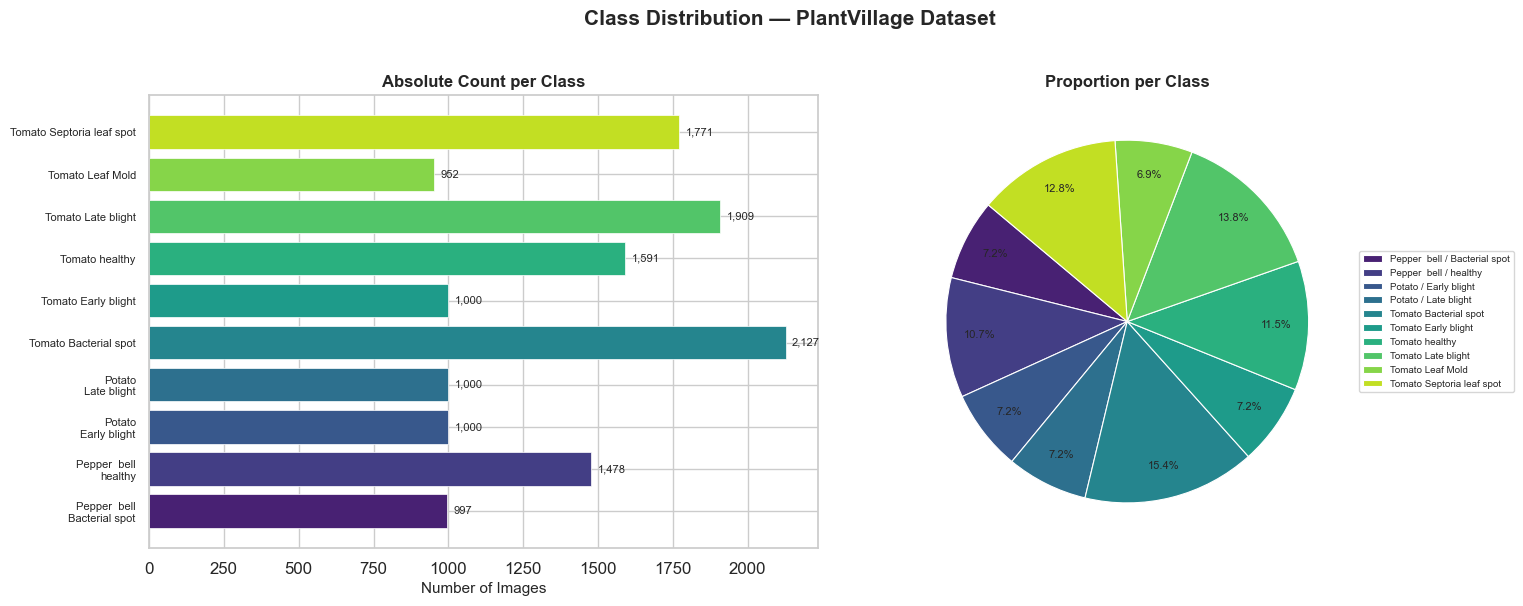

✅ Saved: C:\Users\errac\Desktop\Projet_ING\Computer-Vision\results\plots\part1_exploration\class_distribution.png


In [14]:
counts_sorted = [class_counts[i] for i in range(n_classes)]
short_names   = [n.replace('___', '\n').replace('_', ' ') for n in class_names]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Class Distribution — PlantVillage Dataset', fontsize=15, fontweight='bold', y=1.01)

# ── Bar chart ────────────────────────────────────────────────────────────────
palette = sns.color_palette('viridis', n_classes)
bars = axes[0].barh(range(n_classes), counts_sorted, color=palette, edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(n_classes))
axes[0].set_yticklabels(short_names, fontsize=8)
axes[0].set_xlabel('Number of Images', fontsize=11)
axes[0].set_title('Absolute Count per Class', fontsize=12, fontweight='bold')
for bar, cnt in zip(bars, counts_sorted):
    axes[0].text(bar.get_width() + max(counts_sorted) * 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{cnt:,}', va='center', fontsize=8)

# ── Pie chart ─────────────────────────────────────────────────────────────────
wedges, texts, autotexts = axes[1].pie(
    counts_sorted, labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    colors=palette, startangle=140, pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=0.8)
)
for at in autotexts:
    at.set_fontsize(8)
axes[1].set_title('Proportion per Class', fontsize=12, fontweight='bold')
axes[1].legend(wedges, [n.replace('___', ' / ').replace('_', ' ') for n in class_names],
               loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=7)

plt.tight_layout()
fig.savefig(PLOTS_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {PLOTS_DIR / "class_distribution.png"}')

## 4. Class Balance Analysis

Compute the imbalance ratio and decide whether class weighting is required.

In [15]:
ratio = imbalance_ratio(labels)
class_weights = compute_class_weights(labels)

print('=' * 55)
print('  Class Balance Analysis')
print('=' * 55)
print(f'  Max class size : {max(class_counts.values()):,}')
print(f'  Min class size : {min(class_counts.values()):,}')
print(f'  Mean class size: {int(np.mean(list(class_counts.values()))):,}')
print(f'  Std class size : {int(np.std(list(class_counts.values()))):,}')
print(f'  Imbalance ratio: {ratio:.2f}x')

if ratio > 3.0:
    print()
    print('  ⚠️  Imbalance > 3x detected.')
    print('  → class_weight="balanced" will be applied to SVM and RF.')
    print('  → WeightedRandomSampler will be used in DL DataLoader.')
else:
    print()
    print('  ✅ Dataset is reasonably balanced (ratio ≤ 3x).')
    print('  → No oversampling or class weighting required.')

print()
print(f'  {"Class":<45} {"Weight":>8}')
print('  ' + '-' * 54)
for idx, name in enumerate(class_names):
    print(f'  {name:<45} {class_weights[idx]:>8.4f}')
print('=' * 55)

  Class Balance Analysis
  Max class size : 2,127
  Min class size : 952
  Mean class size: 1,382
  Std class size : 425
  Imbalance ratio: 2.23x

  ✅ Dataset is reasonably balanced (ratio ≤ 3x).
  → No oversampling or class weighting required.

  Class                                           Weight
  ------------------------------------------------------
  Pepper__bell___Bacterial_spot                   1.3867
  Pepper__bell___healthy                          0.9354
  Potato___Early_blight                           1.3825
  Potato___Late_blight                            1.3825
  Tomato_Bacterial_spot                           0.6500
  Tomato_Early_blight                             1.3825
  Tomato_healthy                                  0.8690
  Tomato_Late_blight                              0.7242
  Tomato_Leaf_Mold                                1.4522
  Tomato_Septoria_leaf_spot                       0.7806


## 5. Sample Images per Class

Display representative raw images from each class to understand visual variation.

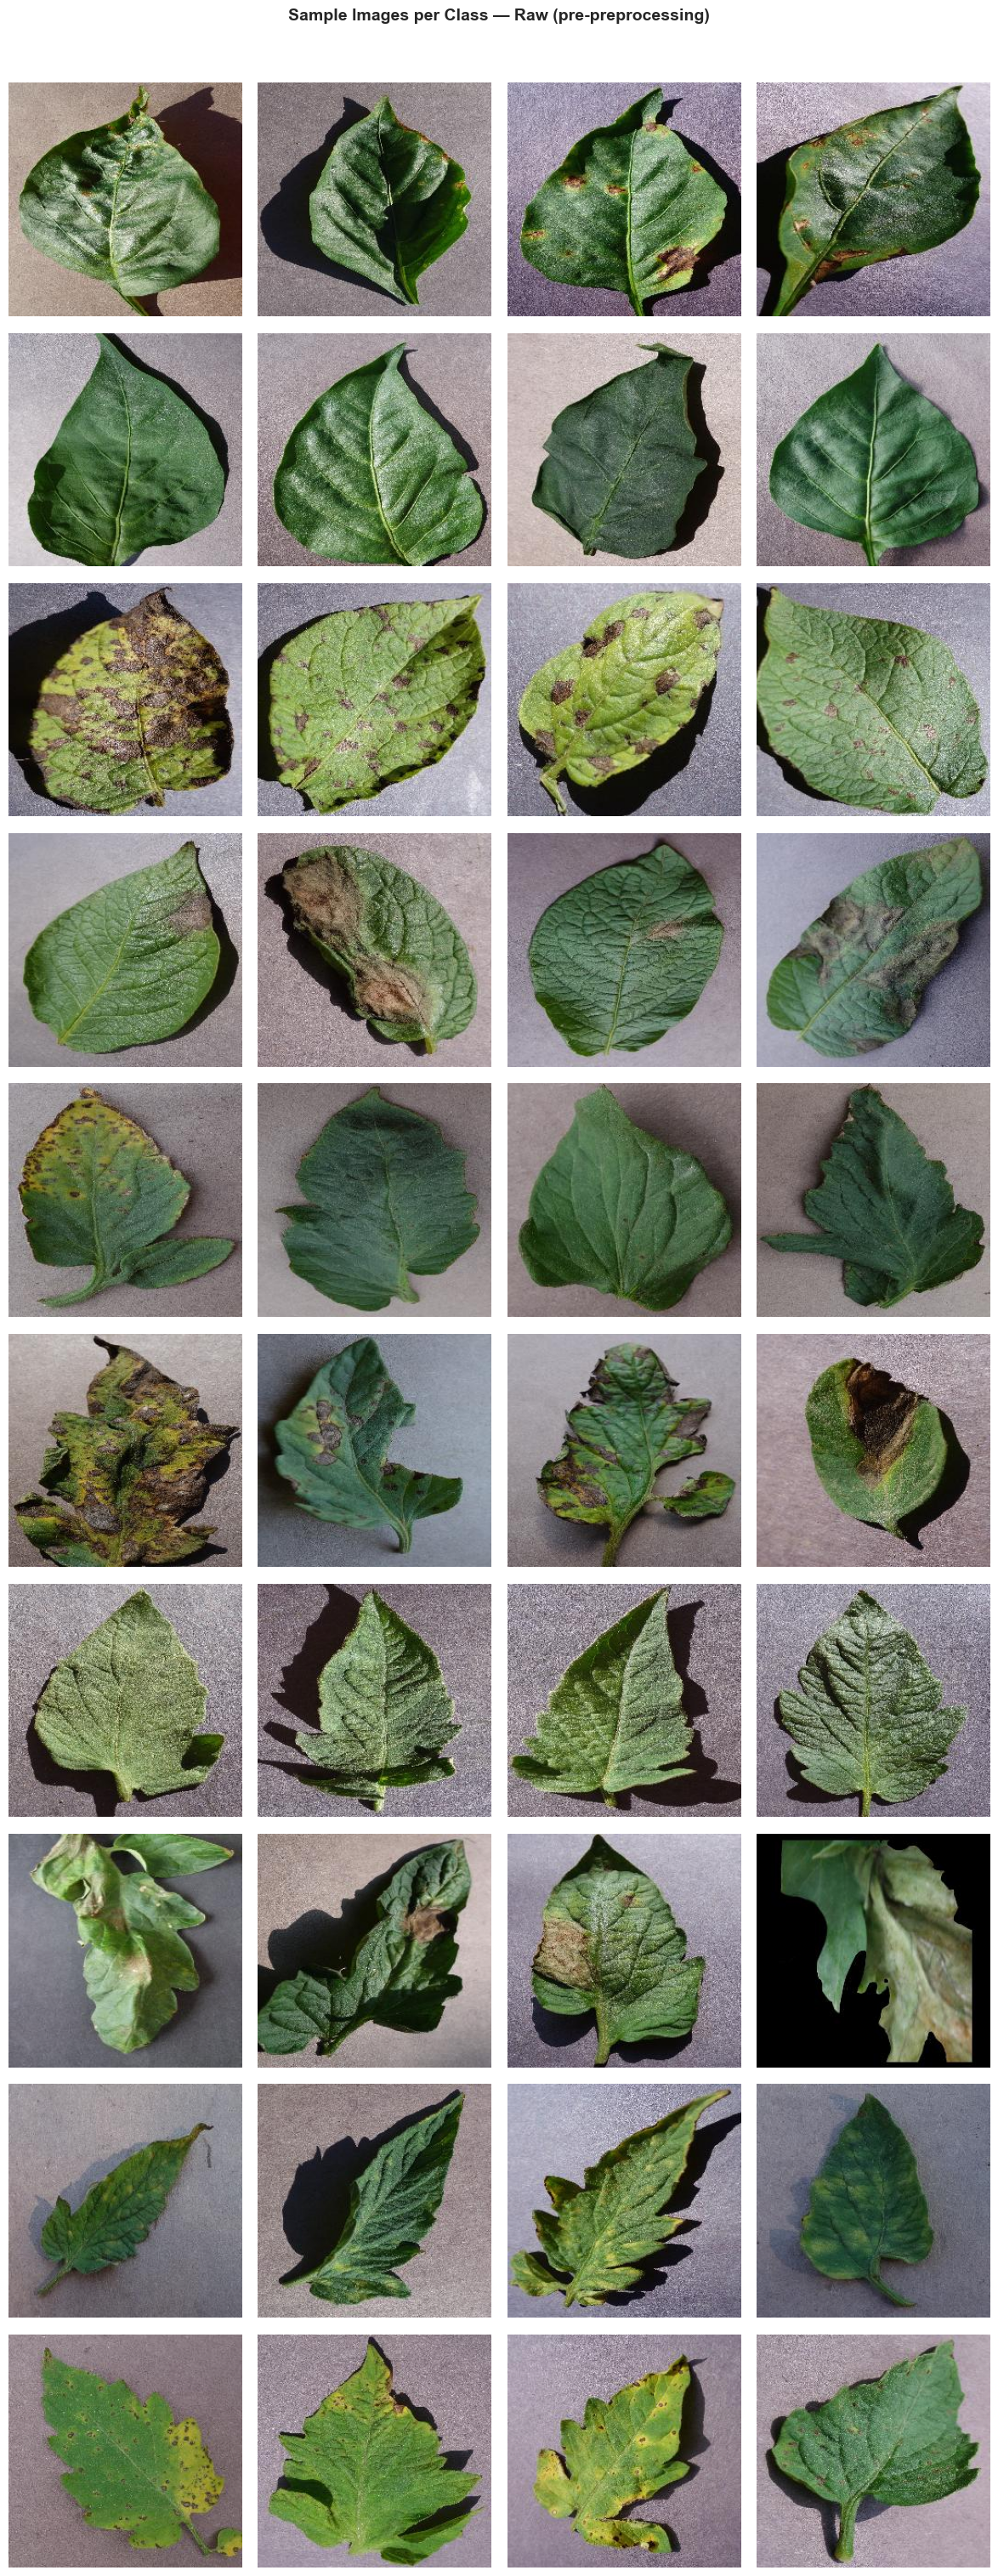

✅ Saved: C:\Users\errac\Desktop\Projet_ING\Computer-Vision\results\plots\part1_exploration\sample_images_raw.png


In [16]:
SAMPLES_PER_CLASS = 4
rng = np.random.default_rng(RANDOM_STATE)

# Collect sample paths per class
class_samples = {}
paths_arr  = np.array(image_paths, dtype=object)
labels_arr = np.array(labels)
for idx in range(n_classes):
    cls_paths = paths_arr[labels_arr == idx]
    chosen = rng.choice(cls_paths, size=min(SAMPLES_PER_CLASS, len(cls_paths)), replace=False)
    class_samples[idx] = chosen.tolist()

# Plot grid: rows = classes, cols = samples
fig, axes = plt.subplots(n_classes, SAMPLES_PER_CLASS, figsize=(SAMPLES_PER_CLASS * 3, n_classes * 3))
fig.suptitle('Sample Images per Class — Raw (pre-preprocessing)', fontsize=14, fontweight='bold', y=1.01)

for row, (cls_idx, sample_paths) in enumerate(class_samples.items()):
    short = class_names[cls_idx].replace('___', '\n').replace('_', ' ')
    for col, path in enumerate(sample_paths):
        ax = axes[row][col] if n_classes > 1 else axes[col]
        img = load_image_rgb(path)
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(short, fontsize=7, rotation=0, labelpad=80, va='center')

plt.tight_layout()
fig.savefig(PLOTS_DIR / 'sample_images_raw.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {PLOTS_DIR / "sample_images_raw.png"}')

## 6. Preprocessing Pipeline Demonstration

Show the effect of each preprocessing step on a sample image:
**Original → Resized → Gaussian Blur → Normalized**

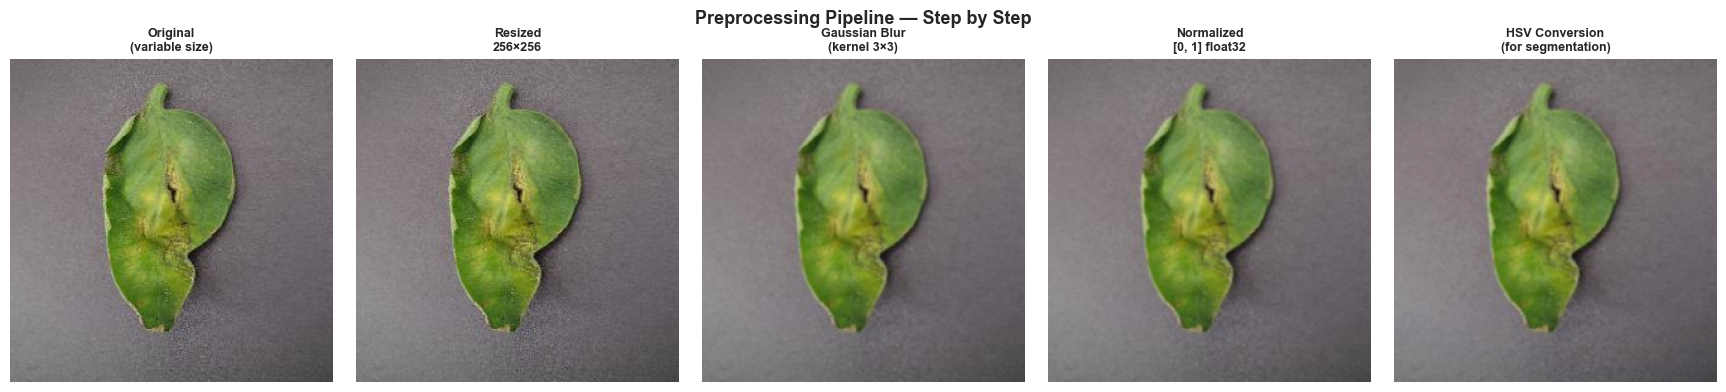

✅ Saved: C:\Users\errac\Desktop\Projet_ING\Computer-Vision\results\plots\part1_exploration\preprocessing_steps.png


In [17]:
import cv2
from src.preprocessing import resize_image, apply_gaussian_blur, normalize_image, convert_to_hsv

# Pick one sample image for demonstration
demo_path = image_paths[rng.integers(0, len(image_paths))]
demo_rgb  = load_image_rgb(demo_path)

step1 = resize_image(demo_rgb)          # 256x256
step2 = apply_gaussian_blur(step1)      # light blur
step3 = normalize_image(step2)          # [0, 1] float32
step4_hsv = cv2.cvtColor(step2, cv2.COLOR_RGB2HSV)  # uint8 HSV

steps = [
    (demo_rgb,   'Original\n(variable size)',      None),
    (step1,      f'Resized\n{TARGET_SIZE[0]}×{TARGET_SIZE[1]}', None),
    (step2,      f'Gaussian Blur\n(kernel {GAUSSIAN_KERNEL[0]}×{GAUSSIAN_KERNEL[1]})', None),
    (step3,      'Normalized\n[0, 1] float32',    None),
    (step4_hsv,  'HSV Conversion\n(for segmentation)', None),
]

fig, axes = plt.subplots(1, len(steps), figsize=(len(steps) * 3.5, 4))
fig.suptitle('Preprocessing Pipeline — Step by Step', fontsize=13, fontweight='bold')

for ax, (img, title, _) in zip(axes, steps):
    display = (img * 255).astype(np.uint8) if img.dtype == np.float32 else img
    if display.ndim == 3 and display.shape[2] == 3 and title.startswith('HSV'):
        # Convert HSV uint8 → RGB for display only
        display = cv2.cvtColor(display, cv2.COLOR_HSV2RGB)
    ax.imshow(display)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
fig.savefig(PLOTS_DIR / 'preprocessing_steps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {PLOTS_DIR / "preprocessing_steps.png"}')

## 7. Train / Validation / Test Split

Apply the approved split strategy: **70% / 15% / 15%**, stratified by class, `random_state=42`.

In [18]:
splits = make_splits(image_paths, labels)

print('Split Strategy: Stratified 70 / 15 / 15')
print(f'Random State  : {RANDOM_STATE}')
print()
print_split_summary(splits, class_names)

Split Strategy: Stratified 70 / 15 / 15
Random State  : 42


Split           N      %  Pepper__bell  Pepper__bell  Potato___Ear  Potato___Lat  Tomato_Bacte  Tomato_Early  Tomato_healt  Tomato_Late_  Tomato_Leaf_  Tomato_Septo
Train        9677  70.0%  698           1034          700           700           1489          700           1114          1336          666           1240        
Val          2073  15.0%  150           222           150           150           319           150           238           286           143           265         
Test         2075  15.0%  149           222           150           150           319           150           239           287           143           266         

Imbalance ratio (train): 2.24x  ✅  Dataset is reasonably balanced



### 7.1 Split Distribution Verification

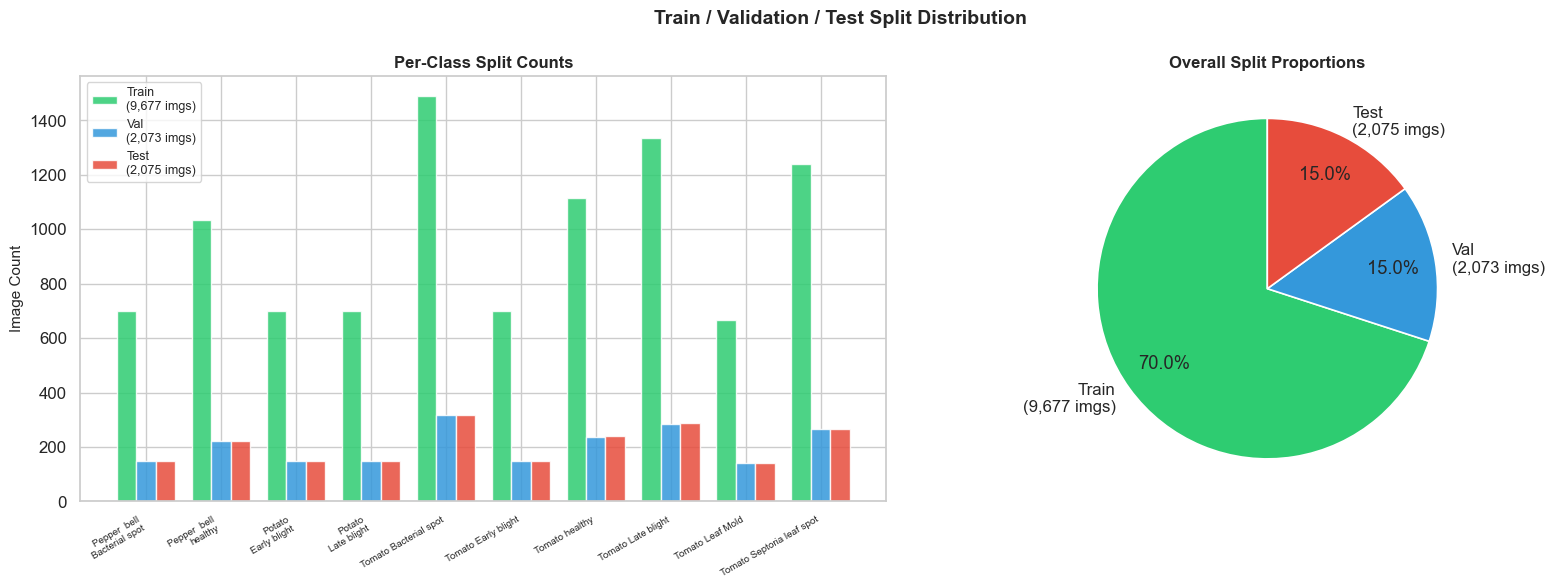

✅ Saved: C:\Users\errac\Desktop\Projet_ING\Computer-Vision\results\plots\part1_exploration\split_distribution.png


In [19]:
split_names    = list(splits.keys())
split_totals   = [len(splits[s][0]) for s in split_names]
split_colors   = ['#2ecc71', '#3498db', '#e74c3c']
split_labels   = [f'{s.capitalize()}\n({t:,} imgs)' for s, t in zip(split_names, split_totals)]

# Build per-class counts for each split
split_class_counts = {}
for split_name in split_names:
    _, lbls = splits[split_name]
    split_class_counts[split_name] = [Counter(lbls).get(i, 0) for i in range(n_classes)]

x = np.arange(n_classes)
width = 0.26

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Train / Validation / Test Split Distribution', fontsize=14, fontweight='bold')

# ── Grouped bar: per-class split counts ──────────────────────────────────────
for i, (sn, color) in enumerate(zip(split_names, split_colors)):
    axes[0].bar(x + (i - 1) * width, split_class_counts[sn], width,
                label=split_labels[i], color=color, alpha=0.85, edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace('___', '\n').replace('_', ' ') for n in class_names],
                         fontsize=7, rotation=30, ha='right')
axes[0].set_ylabel('Image Count', fontsize=11)
axes[0].set_title('Per-Class Split Counts', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# ── Pie: overall split proportions ───────────────────────────────────────────
axes[1].pie(split_totals, labels=split_labels, colors=split_colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.75,
            wedgeprops=dict(edgecolor='white', linewidth=1.2))
axes[1].set_title('Overall Split Proportions', fontsize=12, fontweight='bold')

plt.tight_layout()
fig.savefig(PLOTS_DIR / 'split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {PLOTS_DIR / "split_distribution.png"}')

## 8. Experiment Logging

Save all Phase 1 configuration and results for reproducibility and the final report.

In [20]:
# ── Build the experiment log ──────────────────────────────────────────────────
experiment_log = {
    "phase": "Phase 1 — Dataset Exploration",
    "timestamp": datetime.datetime.now().isoformat(),
    "dataset": {
        "root": str(DATASET_ROOT),
        "n_classes": n_classes,
        "class_names": class_names,
        "total_images": n_images,
        "class_counts": {class_names[i]: class_counts[i] for i in range(n_classes)},
        "imbalance_ratio": round(ratio, 4),
        "class_weights": {class_names[i]: round(class_weights[i], 6) for i in range(n_classes)},
        "balance_status": "balanced" if ratio <= 3.0 else "imbalanced",
    },
    "preprocessing": {
        "target_size": list(TARGET_SIZE),
        "gaussian_kernel": list(GAUSSIAN_KERNEL),
        "normalization": "pixel / 255.0",
        "color_conversion": "RGB → HSV (for segmentation and feature extraction)",
        "excluded_methods": ["grayscale", "histogram_equalization", "median_blur", "bilateral_filter"],
    },
    "split_strategy": {
        "train_ratio": TRAIN_RATIO,
        "val_ratio": VAL_RATIO,
        "test_ratio": round(1 - TRAIN_RATIO - VAL_RATIO, 4),
        "stratified": True,
        "random_state": RANDOM_STATE,
        "sizes": {
            s: len(splits[s][0]) for s in splits
        },
    },
    "outputs": {
        "plots": str(PLOTS_DIR),
        "logs": str(LOGS_DIR),
    },
}

log_path = LOGS_DIR / 'phase1_dataset_exploration.json'
log_path.write_text(json.dumps(experiment_log, indent=2), encoding='utf-8')
print(f'✅ Experiment log saved: {log_path}')
print()
print(json.dumps(experiment_log['dataset'], indent=2))

✅ Experiment log saved: C:\Users\errac\Desktop\Projet_ING\Computer-Vision\results\experiment_logs\phase1_dataset_exploration.json

{
  "root": "C:\\Users\\errac\\Desktop\\Projet_ING\\Computer-Vision\\data\\raw",
  "n_classes": 10,
  "class_names": [
    "Pepper__bell___Bacterial_spot",
    "Pepper__bell___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_healthy",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot"
  ],
  "total_images": 13825,
  "class_counts": {
    "Pepper__bell___Bacterial_spot": 997,
    "Pepper__bell___healthy": 1478,
    "Potato___Early_blight": 1000,
    "Potato___Late_blight": 1000,
    "Tomato_Bacterial_spot": 2127,
    "Tomato_Early_blight": 1000,
    "Tomato_healthy": 1591,
    "Tomato_Late_blight": 1909,
    "Tomato_Leaf_Mold": 952,
    "Tomato_Septoria_leaf_spot": 1771
  },
  "imbalance_ratio": 2.2342,
  "class_weights": {
    "Pepper__bell__

## 9. Phase 1 Summary

| Item | Value |
|---|---|
| Dataset root | `DATASET_ROOT` |
| Total images | N |
| Classes | 10 |
| Preprocessing | Resize 256×256 → Gaussian Blur 3×3 → Normalize /255 |
| Split | 70 / 15 / 15 (stratified, seed=42) |
| Imbalance ratio | Computed above |
| Class weighting | Applied if ratio > 3x |

### Justification of Preprocessing Choices

- **Resize 256×256**: Standard for plant disease classification. Preserves sufficient spatial detail without excessive compute.
- **Gaussian Blur (3×3)**: Light denoising only. Preserves texture structure needed for GLCM features. Heavier kernels would destroy discriminative texture patterns.
- **RGB → HSV**: HSV separates chromatic information (Hue, Saturation) from luminance (Value), making color-based segmentation and feature extraction more robust to lighting changes.
- **Normalization /255**: Standard for deep learning and numerical stability in ML classifiers.
- **Excluded**: Grayscale conversion (loses color info critical for disease identification), histogram equalization (distorts natural color distributions), median/bilateral filtering (unnecessary complexity).

---
**Phase 1 is complete. Proceed to Phase 2: Segmentation.**